c:\Users\carlo\.conda\envs\TODO\lib\site-packages\gymnasium\spaces\box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\carlo\.conda\envs\TODO\lib\site-packages\gymnasium\spaces\box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


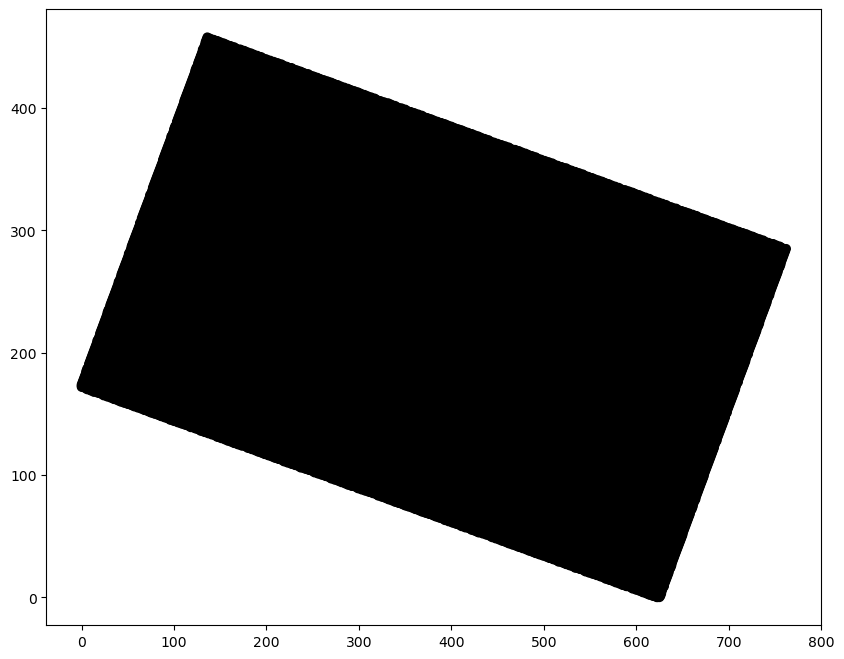

In [ ]:
# ENTORNO DE ENTRADA: env_R11.py (Ruta: Datos/02_Reinforcement_learning/env_R11.py)

import numpy as np
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import env_R11 
env = env_R11.motorEnv() 
import itertools
import pandas as pd
from env_R11 import motorEnv
from tqdm.auto import tqdm 
import warnings
warnings.filterwarnings('ignore')
import os

--- FASE 1: BUSCANDO LOS MEJORES HIPERPARÁMETROS ---


Grid Search:   0%|          | 0/16 [00:00<?, ?it/s]

Comb 1/16:   0%|          | 0/250 [00:00<?, ?it/s]

Comb 2/16:   0%|          | 0/250 [00:00<?, ?it/s]

Comb 3/16:   0%|          | 0/250 [00:00<?, ?it/s]

...

Comb 13/16:   0%|          | 0/250 [00:00<?, ?it/s]

Comb 14/16:   0%|          | 0/250 [00:00<?, ?it/s]

Comb 15/16:   0%|          | 0/250 [00:00<?, ?it/s]

Comb 16/16:   0%|          | 0/250 [00:00<?, ?it/s]


🏆 ¡GRID SEARCH COMPLETADO!
Mejor combinación: Alpha=0.4, Gamma=0.999, Decay=0.99, Multiplicador=300
------------------------------------------------------------
💾 Hiperparámetros guardados automáticamente para la Fase 2.


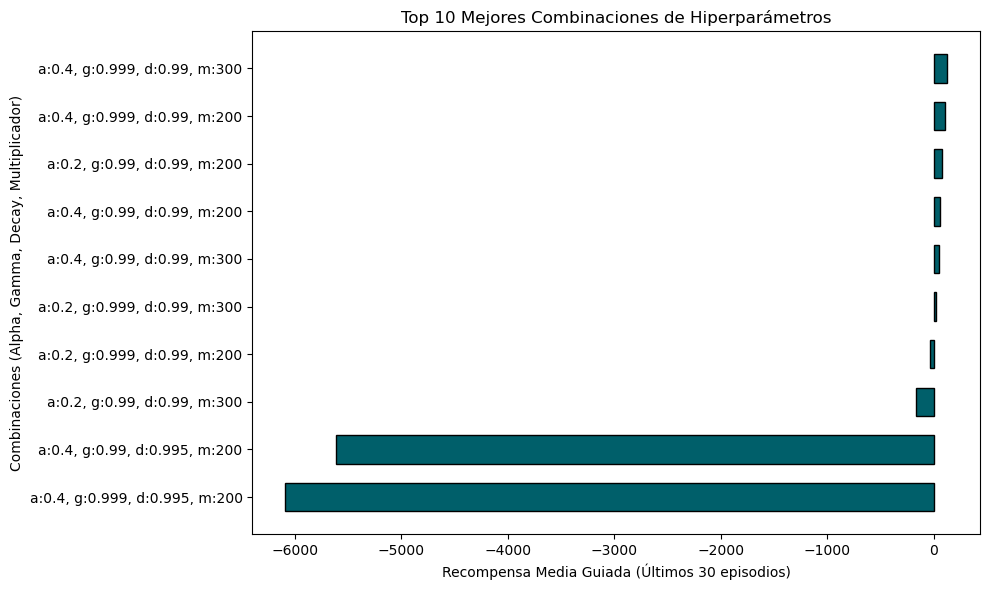

In [ ]:
print("FASE 1: BUSCANDO LOS MEJORES HIPERPARÁMETROS")

# 1. Definimos las combinaciones
alphas = [0.4, 0.2]               
gammas = [0.99, 0.999]            
decays = [0.99, 0.995]            
multiplicadores = [200, 300] 
combinaciones = list(itertools.product(alphas, gammas, decays, multiplicadores))

mejor_recompensa_media = -float('inf')
mejores_parametros = None
episodios_grid_search = 250
resultados = []

# 2. Bucle del Grid Search
for i, (alpha, gamma, decay, mult) in enumerate(tqdm(combinaciones, desc="Grid Search")):
    env = motorEnv()
    num_estados = len(env.rot)
    num_acciones = env.action_space.n
    q_table = np.zeros((num_estados, num_acciones))
    
    epsilon = 1.0
    epsilon_min = 0.01
    recompensas_ultimos_episodios = []
    
    for episodio in tqdm(range(episodios_grid_search), desc=f"Comb {i+1}/{len(combinaciones)}", leave=False):
        env.reset() 
        estado = 0 
        done = False
        pasos_dados = 0
        recompensa_episodio = 0
        
        while not done and pasos_dados < 1500:
            if random.uniform(0, 1) < epsilon:
                accion = env.action_space.sample()
            else:
                accion = np.argmax(q_table[estado])
                
            paso = env.step(accion)
            if len(paso) == 4:
                siguiente_estado, recompensa, done, info = paso
            else:
                siguiente_estado, recompensa, done, truncated, info = paso
                done = done or truncated
                
            # --- FÓRMULA DE BONIFICACIÓN  ---
            w_antiguo = env.rot.iloc[estado]['w']
            w_nuevo = env.rot.iloc[siguiente_estado]['w']
            mejora_w = w_antiguo - w_nuevo 
            
            if estado == siguiente_estado:
                recompensa_guiada = recompensa 
            elif mejora_w > 0:
                recompensa_guiada = recompensa + 3.0 + (mejora_w * mult)
            elif mejora_w < 0:
                recompensa_guiada = recompensa - 3.0 + (mejora_w * mult)
            else:
                recompensa_guiada = recompensa
            
            valor_antiguo = q_table[estado, accion]
            proximo_maximo = np.max(q_table[siguiente_estado])
            q_table[estado, accion] = valor_antiguo + alpha * (recompensa_guiada + gamma * proximo_maximo - valor_antiguo)
            
            estado = siguiente_estado
            
            recompensa_episodio += recompensa_guiada
            pasos_dados += 1
            
        if epsilon > epsilon_min:
            epsilon *= decay
            
        if episodio >= episodios_grid_search - 30:
            recompensas_ultimos_episodios.append(recompensa_episodio)
        plt.close('all')
            
    media_recompensa = np.mean(recompensas_ultimos_episodios)
    resultados.append({'params': (alpha, gamma, decay, mult), 'score': media_recompensa})
    
    if media_recompensa > mejor_recompensa_media:
        mejor_recompensa_media = media_recompensa
        mejores_parametros = (alpha, gamma, decay, mult)

print("\n¡GRID SEARCH COMPLETADO!")
print(f"Mejor combinación: Alpha={mejores_parametros[0]}, Gamma={mejores_parametros[1]}, Decay={mejores_parametros[2]}, Multiplicador={mejores_parametros[3]}")
print("-" * 60)

np.save('Datos/Transformados/mejores_params_R11.npy', mejores_parametros)
print("Hiperparámetros guardados automáticamente para la Fase 2.")
resultados_ordenados = sorted(resultados, key=lambda x: x['score'])
top_resultados = resultados_ordenados[-10:] 
etiquetas = [f"a:{r['params'][0]}, g:{r['params'][1]}, d:{r['params'][2]}, m:{r['params'][3]}" for r in top_resultados]
puntuaciones = [r['score'] for r in top_resultados]
plt.figure(figsize=(10, 6))
plt.barh(etiquetas, puntuaciones, color='#005F6A', edgecolor='black', height=0.6)
plt.xlabel("Recompensa Media Guiada (Últimos 30 episodios)")
plt.ylabel("Combinaciones (Alpha, Gamma, Decay, Multiplicador)")
plt.title("Top 10 Mejores Combinaciones de Hiperparámetros")
plt.tight_layout()
plt.show()

In [ ]:
# BLOQUE 2: ENTRENAMIENTO CON EARLY STOPPING MATRICIAL

print("RECUPERANDO HIPERPARÁMETROS GANADORES")

mejores_parametros = np.load('Datos/Transformados/mejores_params_R11.npy')
alpha_opt, gamma_opt, decay_opt, mult_opt = mejores_parametros
print(f"Cargado: Alpha={alpha_opt}, Gamma={gamma_opt}, Decay={decay_opt}, Multiplicador={mult_opt}")
print("\nINICIANDO ENTRENAMIENTO FINAL (CON EARLY STOPPING)")

env = motorEnv()
num_estados = len(env.rot)
num_acciones = env.action_space.n
q_table = np.zeros((num_estados, num_acciones))
epsilon = 1.0
epsilon_min = 0.01
max_episodios = 3000          
umbral_convergencia = 1e-4   
paciencia = 10             
contador_paciencia = 0        

for episodio in tqdm(range(max_episodios), desc="Entrenando (Buscando Convergencia)"):
    env.reset() 
    estado = 0 
    done = False
    pasos_dados = 0
    
    old_q_table = np.copy(q_table)
    
    while not done and pasos_dados < 1500:
        if random.uniform(0, 1) < epsilon:
            accion = env.action_space.sample()
        else:
            accion = np.argmax(q_table[estado])
        paso = env.step(accion)
        if len(paso) == 4:
            siguiente_estado, recompensa, done, info = paso
        else:
            siguiente_estado, recompensa, done, truncated, info = paso
            done = done or truncated
            
        w_antiguo = env.rot.iloc[estado]['w']
        w_nuevo = env.rot.iloc[siguiente_estado]['w']
        mejora_w = w_antiguo - w_nuevo 
        
        if estado == siguiente_estado:
            recompensa_guiada = recompensa 
        elif mejora_w > 0:
            recompensa_guiada = recompensa + 3.0 + (mejora_w * mult_opt)
        elif mejora_w < 0:
            recompensa_guiada = recompensa - 3.0 + (mejora_w * mult_opt)
        else:
            recompensa_guiada = recompensa
        
        valor_antiguo = q_table[estado, accion]
        proximo_maximo = np.max(q_table[siguiente_estado])
        q_table[estado, accion] = valor_antiguo + alpha_opt * (recompensa_guiada + gamma_opt * proximo_maximo - valor_antiguo)
        
        estado = siguiente_estado
        pasos_dados += 1
        
    if epsilon > epsilon_min:
        epsilon *= decay_opt
    diferencia_maxima = np.max(np.abs(q_table - old_q_table))
    if diferencia_maxima < umbral_convergencia:
        contador_paciencia += 1
    else:
        contador_paciencia = 0 
        
    if contador_paciencia >= paciencia:
        print(f"\nEl entrenamiento se detuvo temprano en el episodio {episodio + 1}.")
        print(f"La mayor actualización en la Q-Table fue de {diferencia_maxima:.6f} (menor que el umbral de {umbral_convergencia}).")
        break
    plt.close('all')

# EXTRACCIÓN DEL CAMINO 
print("\nPONIENDO A PRUEBA AL AGENTE FINAL")
env.reset()
estado = 0
done = False
pasos_dados = 0
recompensa_oficial_total = 0

camino_var1, camino_var2, camino_w = [], [], []
while not done and pasos_dados < 1500:
    camino_var1.append(env.rot.iloc[estado]['var1'])
    camino_var2.append(env.rot.iloc[estado]['var2'])
    camino_w.append(env.rot.iloc[estado]['w'])
    
    accion = np.argmax(q_table[estado])
    
    paso = env.step(accion)
    if len(paso) == 4:
        estado, recompensa, done, info = paso
    else:
        estado, recompensa, done, truncated, info = paso
        done = done or truncated
        
    recompensa_oficial_total += recompensa 
    pasos_dados += 1

camino_var1.append(env.rot.iloc[estado]['var1'])
camino_var2.append(env.rot.iloc[estado]['var2'])
camino_w.append(env.rot.iloc[estado]['w'])
plt.close('all')
df_ruta = pd.DataFrame({'paso_num': range(len(camino_var1)), 'var1': camino_var1, 'var2': camino_var2, 'consumo_W': camino_w})
df_ruta.to_csv("Datos/Transformados/03_ruta_optima_RL.csv", index=False)

pasos_totales = len(df_ruta) - 1
print(f"DATOS GUARDADOS EN '03_ruta_optima_RL.csv'")
print(f"PASOS TOTALES DEL CAMINO: {pasos_totales} pasos")
print(f"CONSUMO FINAL: {camino_w[-1]:.2f} W")

--- RECUPERANDO HIPERPARÁMETROS GANADORES ---
✅ Cargado exitosamente: Alpha=0.4, Gamma=0.999, Decay=0.99, Multiplicador=300.0
------------------------------------------------------------

--- INICIANDO ENTRENAMIENTO FINAL (CON EARLY STOPPING) ---


Entrenando (Buscando Convergencia):   0%|          | 0/3000 [00:00<?, ?it/s]


--- PONIENDO A PRUEBA AL AGENTE FINAL ---
--------------------------------------------------
✅ DATOS GUARDADOS EN '03_ruta_optima_RL.csv'
🚶‍♂️ PASOS TOTALES DEL CAMINO: 533 pasos
📉 CONSUMO FINAL: 20.86 W
--------------------------------------------------



--- GENERANDO GRÁFICAS DE RUTA ---


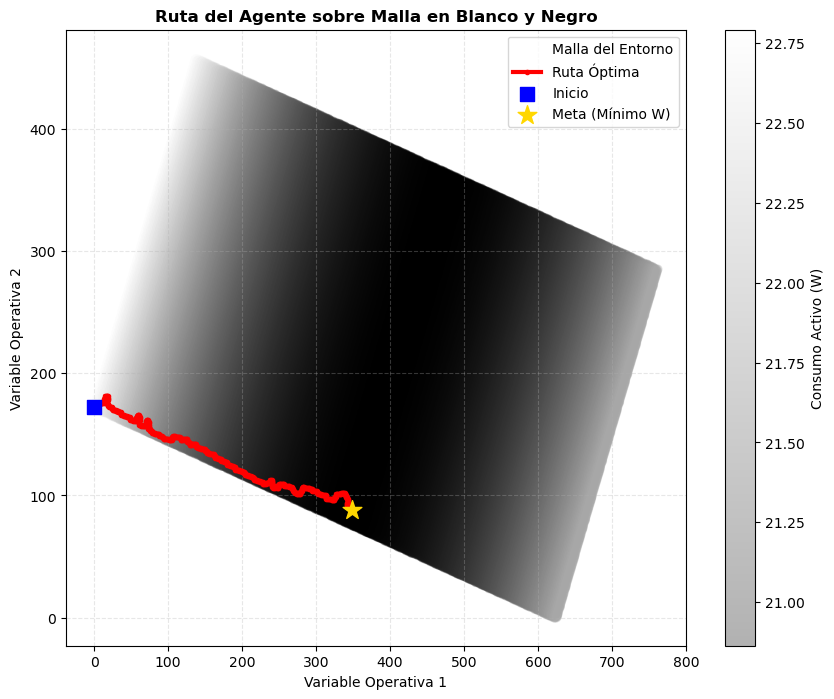

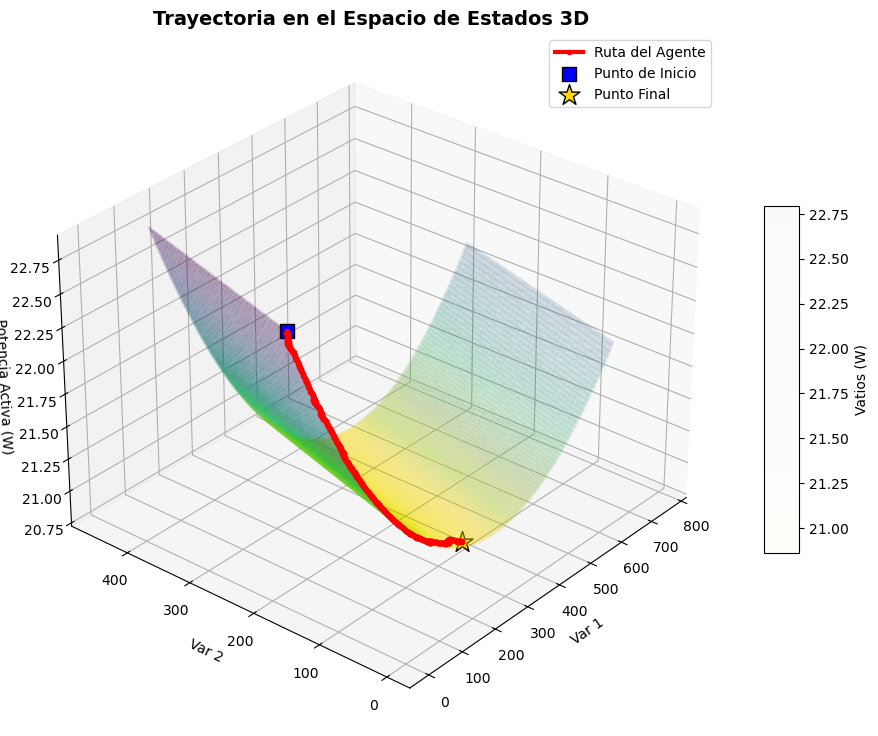

In [ ]:
# BLOQUE 3: VISUALIZACIÓN DE RESULTADOS (2D y 3D)


print("\nGENERANDO GRÁFICAS DE RUTA")

df_fondo = pd.read_csv('Datos/02_Reinforcement_learning/Datos_v1.csv')
df_fondo = df_fondo.drop('index', axis=1, errors='ignore')
df_ruta = pd.read_csv("03_ruta_optima_RL.csv")

# GRÁFICO 1: MALLA EN BLANCO Y NEGRO (2D)
plt.figure(figsize=(10, 8))
plt.scatter(df_fondo['var1'], df_fondo['var2'], c=df_fondo['w'], cmap='gray', alpha=0.3, label='Malla del Entorno')
cb = plt.colorbar()
cb.set_label('Consumo Activo (W)')
plt.plot(df_ruta['var1'], df_ruta['var2'], color='red', linewidth=3, marker='o', markersize=3, label='Ruta Óptima')
plt.scatter(df_ruta['var1'].iloc[0], df_ruta['var2'].iloc[0], color='blue', s=100, marker='s', label='Inicio', zorder=5)
plt.scatter(df_ruta['var1'].iloc[-1], df_ruta['var2'].iloc[-1], color='gold', s=200, marker='*', label='Meta (Mínimo W)', zorder=5)
plt.title("Ruta del Agente sobre Malla en Blanco y Negro", fontweight='bold')
plt.xlabel("Variable Operativa 1")
plt.ylabel("Variable Operativa 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

# GRÁFICO 2: EL ENTORNO 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(df_fondo['var1'], df_fondo['var2'], df_fondo['w'], c=df_fondo['w'], cmap='viridis_r', alpha=0.02, s=2)
ax.plot(df_ruta['var1'], df_ruta['var2'], df_ruta['consumo_W'], color='red', linewidth=3, marker='o', markersize=3, alpha=1.0, label='Ruta del Agente', zorder=10)
ax.scatter(df_ruta['var1'].iloc[0], df_ruta['var2'].iloc[0], df_ruta['consumo_W'].iloc[0], color='blue', s=100, marker='s', edgecolors='black', label='Punto de Inicio', zorder=15)
ax.scatter(df_ruta['var1'].iloc[-1], df_ruta['var2'].iloc[-1], df_ruta['consumo_W'].iloc[-1], color='gold', s=250, marker='*', edgecolors='black', label='Punto Final', zorder=15)
ax.set_title("Trayectoria en el Espacio de Estados 3D", fontweight='bold', fontsize=14)
ax.set_xlabel("Var 1")
ax.set_ylabel("Var 2")
ax.set_zlabel("Potencia Activa (W)")
ax.view_init(elev=30, azim=220) 
fig.colorbar(p, ax=ax, label='Vatios (W)', shrink=0.5, aspect=10)
ax.legend()
plt.show()